# SQL Product Analytics Case Study

## Introduction

This project analyzes transactional and customer data from a Brazilian e-commerce platform using SQL and Python.

The goal of the analysis is to explore user behavior, revenue trends, product performance, and customer retention in order to uncover actionable business insights.

The project includes:
- revenue analysis
- monthly order trends
- top product categories
- average order value (AOV)
- cohort retention analysis

SQL is used for data extraction and aggregation, while Python is used for visualization and interpretation of results.

## Dataset

The analysis uses the **Brazilian E-Commerce Public Dataset by Olist**, available on Kaggle.

The dataset contains real anonymized e-commerce transactions, including:
- customer information
- orders
- payments
- products
- order items

It provides a comprehensive view of user purchasing behavior on a large online marketplace.

Source: Kaggle — Brazilian E-Commerce Public Dataset by Olist

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect('ecommerce.db')

In [2]:
orders = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-egor-sakulin-wkf7957/Product_project/olist_orders_dataset.csv')
payments = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-egor-sakulin-wkf7957/Product_project/olist_order_payments_dataset.csv')
items = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-egor-sakulin-wkf7957/Product_project/olist_order_items_dataset.csv')
products = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-egor-sakulin-wkf7957/Product_project/olist_products_dataset.csv')

In [3]:
orders.to_sql('orders', conn, if_exists='replace', index=False)
payments.to_sql('payments', conn, if_exists='replace', index=False)
items.to_sql('order_items', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)

32951

## Total Orders

We calculate the total number of orders to understand the scale of the e-commerce platform.

In [4]:
query = """
SELECT COUNT(*) AS total_orders
FROM orders;
"""

pd.read_sql(query, conn)

,total_orders
0,99441


## Revenue Analysis

Total revenue helps evaluate the overall business performance of the platform.

In [5]:
query = """
SELECT ROUND(SUM(payment_value), 2) AS total_revenue
FROM payments;
"""

pd.read_sql(query, conn)

,total_revenue
0,16008872.12


## Monthly Orders Trend

In [6]:
query = """
SELECT 
    SUBSTR(order_purchase_timestamp, 1, 7) AS month,
    COUNT(*) AS total_orders
FROM orders
GROUP BY month
ORDER BY month;
"""

monthly_orders = pd.read_sql(query, conn)

monthly_orders

,month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [7]:
monthly_orders = monthly_orders[
    ~monthly_orders['month'].isin(['2018-09', '2018-10'])
]

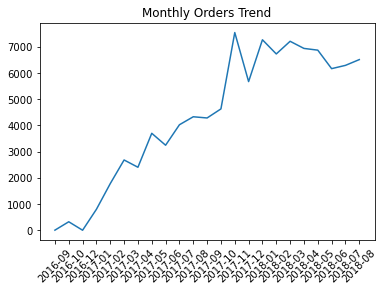

In [8]:
plt.plot(monthly_orders['month'], monthly_orders['total_orders'])
plt.xticks(rotation=45)
plt.title('Monthly Orders Trend')
plt.show()

The number of orders shows strong growth over time, indicating increasing platform activity and user adoption.

Incomplete months at the end of the dataset were excluded from the analysis to avoid misleading conclusions.

## Top Product Categories

We identify the most purchased product categories to better understand customer demand and purchasing behavior.

In [9]:
query = """
SELECT 
    product_category_name,
    COUNT(*) AS purchases
FROM products p
JOIN order_items oi
ON p.product_id = oi.product_id
GROUP BY product_category_name
ORDER BY purchases DESC
LIMIT 10;
"""

top_categories = pd.read_sql(query, conn)

top_categories

,product_category_name,purchases
0,cama_mesa_banho,11115
1,beleza_saude,9670
2,esporte_lazer,8641
3,moveis_decoracao,8334
4,informatica_acessorios,7827
5,utilidades_domesticas,6964
6,relogios_presentes,5991
7,telefonia,4545
8,ferramentas_jardim,4347
9,automotivo,4235


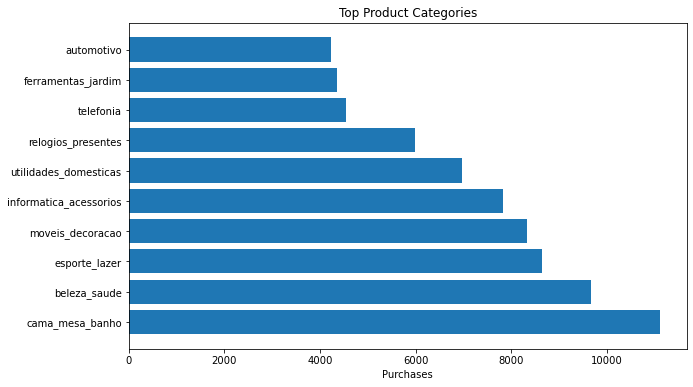

In [10]:
plt.figure(figsize=(10,6))

plt.barh(
    top_categories['product_category_name'],
    top_categories['purchases']
)

plt.title('Top Product Categories')
plt.xlabel('Purchases')

plt.show()

## Key Insights

Home-related and lifestyle product categories generate the highest number of purchases on the platform.

This suggests that customer demand is concentrated around everyday household and personal lifestyle products.

These categories may represent key revenue drivers and should be prioritized in:
- marketing campaigns
- recommendation systems
- inventory optimization

## Average Order Value (AOV)

Average Order Value measures how much revenue is generated per order.

In [11]:
query = """
SELECT 
    ROUND(SUM(payment_value) / COUNT(DISTINCT order_id), 2) AS AOV
FROM payments;
"""

pd.read_sql(query, conn)

,AOV
0,160.99


## Key Insight

The Average Order Value (AOV) is 160.99 BRL.

This indicates that users tend to make moderately high-value purchases, suggesting healthy monetization potential for the platform.

AOV is an important metric because even small improvements can significantly increase total revenue at scale.

## Monthly Revenue Trend

We analyze revenue dynamics over time to evaluate business growth and seasonality patterns.

In [12]:
query = """
SELECT 
    SUBSTR(o.order_purchase_timestamp, 1, 7) AS month,
    ROUND(SUM(p.payment_value), 2) AS revenue
FROM orders o
JOIN payments p
ON o.order_id = p.order_id
GROUP BY month
ORDER BY month;
"""

monthly_revenue = pd.read_sql(query, conn)

monthly_revenue

,month,revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


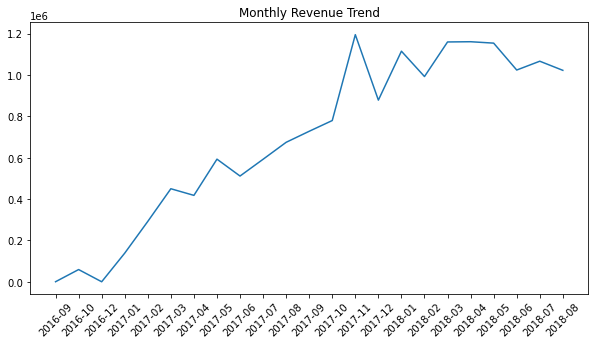

In [13]:
monthly_revenue = monthly_revenue[
    ~monthly_revenue['month'].isin(['2018-09', '2018-10'])
]
plt.figure(figsize=(10,5))

plt.plot(
    monthly_revenue['month'],
    monthly_revenue['revenue']
)

plt.xticks(rotation=45)

plt.title('Monthly Revenue Trend')

plt.show()

## Key Insights

Revenue shows strong growth throughout 2017, followed by stabilization at a high level in 2018.

A significant spike appears in late 2017, likely driven by seasonal effects such as Black Friday and holiday shopping.

This suggests that the platform experienced rapid business expansion and increasing customer activity over time.

## Cohort Retention Analysis

Cohort analysis helps evaluate user retention by tracking whether customers return and place orders in future months.

In [14]:
customers = pd.read_csv('/mnt/HC_Volume_18315164/home-jupyter/jupyter-egor-sakulin-wkf7957/Product_project/olist_customers_dataset.csv')

customers.to_sql(
    'customers',
    conn,
    if_exists='replace',
    index=False
)

99441

In [15]:
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        SUBSTR(o.order_purchase_timestamp, 1, 7) AS order_month
    FROM orders o
    JOIN customers c
    ON o.customer_id = c.customer_id
),

first_purchase AS (
    SELECT
        customer_unique_id,
        MIN(order_month) AS cohort_month
    FROM customer_orders
    GROUP BY customer_unique_id
)

SELECT
    fp.cohort_month,
    co.order_month,
    COUNT(DISTINCT co.customer_unique_id) AS users
FROM customer_orders co
JOIN first_purchase fp
ON co.customer_unique_id = fp.customer_unique_id
GROUP BY fp.cohort_month, co.order_month
ORDER BY fp.cohort_month, co.order_month;
"""

cohort_data = pd.read_sql(query, conn)

cohort_data.head()

,cohort_month,order_month,users
0,2016-09,2016-09,4
1,2016-10,2016-10,321
2,2016-10,2017-04,1
3,2016-10,2017-07,1
4,2016-10,2017-09,1


In [16]:
cohort_data['cohort_month'] = pd.to_datetime(
    cohort_data['cohort_month']
)

cohort_data['order_month'] = pd.to_datetime(
    cohort_data['order_month']
)

In [17]:
cohort_data['cohort_index'] = (
    (cohort_data['order_month'].dt.year -
     cohort_data['cohort_month'].dt.year) * 12
    +
    (cohort_data['order_month'].dt.month -
     cohort_data['cohort_month'].dt.month)
)

In [18]:
cohort_pivot = cohort_data.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='users'
)

cohort_pivot.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12-01,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02-01,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN


In [19]:
cohort_size = cohort_pivot.iloc[:,0]

retention = cohort_pivot.divide(
    cohort_size,
    axis=0
)

retention.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,1.0,NaN,NaN,NaN,NaN,NaN,0.003115,NaN,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,0.006231,0.006231
2016-12-01,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,1.0,0.003927,0.002618,0.001309,0.003927,0.001309,0.005236,0.001309,0.001309,NaN,0.003927,0.001309,0.007853,0.003927,0.001309,0.001309,0.002618,0.003927,0.001309,NaN
2017-02-01,1.0,0.002283,0.002854,0.001142,0.003995,0.001142,0.002283,0.001712,0.001712,0.002283,0.001142,0.002854,0.001712,0.001712,0.001142,0.000571,0.000571,0.002283,NaN,NaN


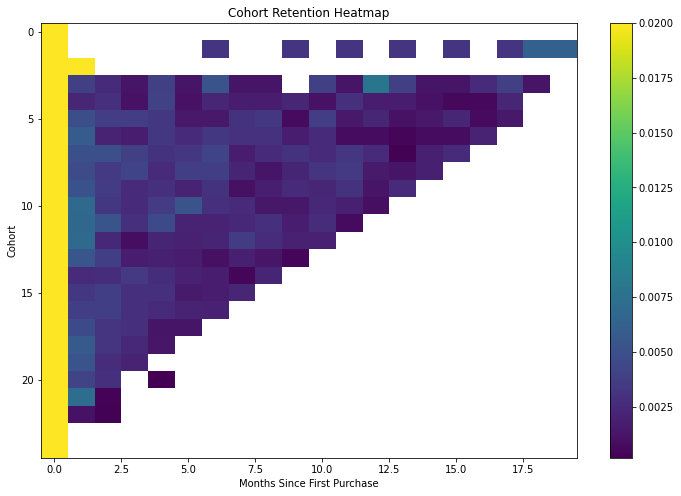

In [20]:
#retention = retention.fillna(0)

plt.figure(figsize=(12,8))

plt.imshow(
    retention,
    aspect='auto',
    cmap='viridis',
    vmax=0.02
)

plt.colorbar()

plt.title('Cohort Retention Heatmap')

plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort')

plt.show()

## Retention Interpretation

The cohort retention analysis shows a sharp decline in user retention after the first purchase.

Most customers do not return in subsequent months, while only a small percentage become repeat buyers.

This suggests that the platform relies heavily on new customer acquisition rather than long-term customer loyalty.

Improving retention could significantly increase customer lifetime value and overall business performance.

# Final Conclusion

This analysis explored customer behavior, revenue trends, product performance, and retention patterns using SQL and Python.

Key findings:
- The platform experienced strong revenue and order growth over time
- Home and lifestyle categories generated the highest number of purchases
- Average Order Value (AOV) reached 160.99 BRL, indicating solid monetization potential
- Customer retention remained very low after the first purchase

The retention analysis suggests that the business relies heavily on acquiring new customers rather than retaining existing ones.

Potential areas for improvement include:
- customer loyalty programs
- personalized recommendations
- re-engagement campaigns
- improved post-purchase experience